In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/spam_ham_dataset.csv')

# Function to split the dataset into 4 parts
def divide_csv(file_path):
    df = pd.read_csv(file_path)
    total_rows = len(df)
    rows_per_part = total_rows // 4
    parts = []
    for i in range(4):
        start_index = i * rows_per_part
        end_index = start_index + rows_per_part if i < 3 else total_rows
        part_df = df.iloc[start_index:end_index]
        parts.append(part_df)
    return parts

# Split the dataset and save to separate files
parts = divide_csv('C:/Users/Admin/Desktop/fwdproject/content/spam_ham_dataset.csv')
for i, part in enumerate(parts):
    part.to_csv(f"part_{i+1}.csv", index=False)


In [13]:
%pip install flwr
%pip install plotly



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB 187.9 kB/s eta 0:01:28
   ---------------------------------------- 0.0/16.4 MB 187.9 kB/s eta 0:01:28
   ---------------------------------------- 0.1/16.4 MB 273.8 kB/s eta 0:01:00
   ---------------------------------------- 0.1/16.4 MB 409.6 kB/s eta 0:00:40
   ---------------------------------------- 0.2/16.4 MB 510.2 kB/s eta 0:00:32
   ---------------------------------------- 0.2/16.4 MB 567.2 kB/s eta 0:00:29
    --------------------------------------- 0.2/16.4 MB 600.7 kB/s eta 0:00:27
    --------------------------------------- 0.3/16.4 MB 656.1 kB/s eta 0:00:25
    -------------


[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import flwr as fl
import threading

def start_server():
    def weighted_average(metrics):
        accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
        examples = [num_examples for num_examples, _ in metrics]
        return {"accuracy": sum(accuracies) / sum(examples)}

    strategy = fl.server.strategy.FedAvg(
        evaluate_metrics_aggregation_fn=weighted_average
    )

    fl.server.start_server(server_address="localhost:8081", config={"num_rounds": 5}, strategy=strategy)

# Start the server in a background thread
server_thread = threading.Thread(target=start_server)
server_thread.start()


INFO :      Starting Flower server, config: {'num_rounds': 5}


Exception in thread Thread-7 (start_server):
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_1184\1276251030.py", line 14, in start_server
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flwr\server\app.py", line 166, in start_server
    grpc_server = start_grpc_server(
                  ^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flwr\server\superlink\fleet\grpc_bidi\grpc_server.py", line 140, in start_grpc_server
    server = generic_create_g

In [6]:
import flwr as fl
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import threading

class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

def client_fn(cid: str):
    data_path = f"C:/Users/Admin/Desktop/fwdproject/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()


	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown bel

In [7]:
#  Importing the Libraries & Loading data

# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
import nltk #Natural Language Toolkit
#To ignore warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [8]:
#Load data & print samples
df = pd.read_csv('C:/Users/Admin/Desktop/fwdproject/content/part_1.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [9]:
#Let's drop the non-relevant unnamed columns
#df=df.drop(['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'],axis=1)

# Renaming v1 & v2 as Category & Text
df=df.rename(columns={"v1":"label","v2":"Text"})

#Sample post modifications
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [10]:
# Exploratory Data Analysis

#Let's check the length of the dataset
print(" Total number of rows in the dataset are", len(df))

 Total number of rows in the dataset are 1292


In [11]:
#Descriptive Summary of the dataset
df.describe()

,Unnamed: 0,label_num
count,1292.000000,1292.000000
mean,2561.602941,0.287152
std,1470.906843,0.452608
min,0.000000,0.000000
25%,1320.500000,0.000000
50%,2551.500000,0.000000
75%,3825.000000,1.000000
max,5162.000000,1.000000


In [14]:
#Let's create a column to check of each text & plot a histogram to check the distirbution
df['Length']=df['text'].apply(len)
display(df.head())

#distribution of the data
import plotly.express as px
fig = px.histogram(df, x='Length', marginal='rug',
                   title='Histogram of Text Length')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

,Unnamed: 0,label,text,label_num,Length
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,414
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,336


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Length=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'offsetgroup': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'histogram',
              'x': array([ 327,   97, 2524, ...,  209,  429,  307], dtype=int64),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'boxpoints': 'all',
              'fillcolor': 'rgba(255,255,255,0)',
              'hoveron': 'points',
              'hovertemplate': 'Length=%{x}<extra></extra>',
              'jitter': 0,
              'legendgroup': '',
              'line': {'color': 'rgba(255,255,255,0)'},
              'marker': {'color': '#636efa', 'symbol': 'line-ns-open'},
              'name': '',
              'offsetgroup': '',
              'showlegend': False,
              'type': 'box',
              'x': array([ 327,   97, 2524, ...,  209,  429,  307], dtype=int64),
              'xaxis': 'x2',
              'yaxis': 'y2'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'showlegend': True,
               'template': '...',
               'title': {'text': 'Histogram of Text Length'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Length'}},
               'xaxis2': {'anchor': 'y2', 'domain': [0.0, 1.0], 'matches': 'x', 'showgrid': True, 'showticklabels': False},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 0.8316], 'title': {'text': 'Frequency'}},
               'yaxis2': {'anchor': 'x2',
                          'domain': [0.8416, 1.0],
                          'matches': 'y2',
                          'showgrid': False,
                          'showline': False,
                          'showticklabels': False,
                          'ticks': ''}}
})

In [15]:
#Lets check the distribution against categories
import plotly.express as px
fig = px.histogram(df, x='Length', color='label', marginal='rug',
                   title='Histogram of Text Length by Category')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'label=ham<br>Length=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'ham',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'ham',
              'offsetgroup': 'ham',
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': array([ 327,   97, 2524, ...,  209,  429,  307], dtype=int64),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'boxpoints': 'all',
              'fillcolor': 'rgba(255,255,255,0)',
              'hoveron': 'points',
              'hovertemplate': 'label=ham<br>Length=%{x}<extra></extra>',
              'jitter': 0,
              'legendgroup': 'ham',
              'line': {'color': 'rgba(255,255,255,0)'},
              'marker': {'color': '#636efa', 'symbol': 'line-ns-open'},
              'name': 'ham',
              'offsetgroup': 'ham',
              'showlegend': False,
              'type': 'box',
              'x': array([ 327,   97, 2524, ...,  209,  429,  307], dtype=int64),
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'label=spam<br>Length=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'spam',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'spam',
              'offsetgroup': 'spam',
              'orientation': 'v',
              'showlegend': True,
              'type': 'histogram',
              'x': array([ 414,  784, 6922, ..., 1064,   11, 1726], dtype=int64),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'boxpoints': 'all',
              'fillcolor': 'rgba(255,255,255,0)',
              'hoveron': 'points',
              'hovertemplate': 'label=spam<br>Length=%{x}<extra></extra>',
              'jitter': 0,
              'legendgroup': 'spam',
              'line': {'color': 'rgba(255,255,255,0)'},
              'marker': {'color': '#EF553B', 'symbol': 'line-ns-open'},
              'name': 'spam',
              'offsetgroup': 'spam',
              'showlegend': False,
              'type': 'box',
              'x': array([ 414,  784, 6922, ..., 1064,   11, 1726], dtype=int64),
              'xaxis': 'x2',
              'yaxis': 'y2'}],
    'layout': {'barmode': 'relative',
               'legend': {'title': {'text': 'label'}, 'tracegroupgap': 0},
               'showlegend': True,
               'template': '...',
               'title': {'text': 'Histogram of Text Length by Category'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Length'}},
               'xaxis2': {'anchor': 'y2', 'domain': [0.0, 1.0], 'matches': 'x', 'showgrid': True, 'showticklabels': False},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 0.7326], 'title': {'text': 'Frequency'}},
               'yaxis2': {'anchor': 'x2',
                          'domain': [0.7426, 1.0],
                          'matches': 'y2',
                          'showgrid': False,
                          'showline': False,
                          'showticklabels': False,
                          'ticks': ''}}
})

In [16]:
#Let's Label the data as 0 & 1 i.e. Spam as 1 & Ham as 0
df.loc[:,'label']=df.label.map({'ham':0, 'spam':1})
df['label'] = df['label'].astype(int)
df.head()

,Unnamed: 0,label,text,label_num,Length
0,605,0,Subject: enron methanol ; meter # : 988291\r\n...,0,327
1,2349,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,97
2,3624,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,2524
3,4685,1,"Subject: photoshop , windows , office . cheap ...",1,414
4,2030,0,Subject: re : indian springs\r\nthis deal is t...,0,336


In [17]:
# Bag of Words

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

count = CountVectorizer()
text = count.fit_transform(df['text'])
#Train & test split
x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)
text

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 112008 stored elements and shape (1292, 21565)>

In [18]:
#Let's print the dimentions of the train & test dataset
display('X-Train :', x_train.shape)
display('X-Test :',x_test.shape)
display('Y-Train :',y_train.shape)
display('X-Test :',y_test.shape)

'X-Train :'

(904, 21565)

'X-Test :'

(388, 21565)

'Y-Train :'

(904,)

'X-Test :'

(388,)

In [20]:
# Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the MLP classifier
mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)

# Train the model
mlp_classifier_model.fit(x_train, y_train)

# Make predictions on the test set
prediction = mlp_classifier_model.predict(x_test)

# Calculate and print classification metrics
print("MLP Classifier")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction)))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction)))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction)))


MLP Classifier
Accuracy score: 0.97
Precision score: 0.92
Recall score: 0.97
F1 score: 0.94


In [22]:
%%time
# Import necessary libraries
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the Multinomial Naive Bayes classifier
multinomial_nb_model = MultinomialNB()

# Train the model
multinomial_nb_model.fit(x_train, y_train)

# Make predictions on the test set
prediction = multinomial_nb_model.predict(x_test)

# Calculate and print classification metrics
print("Multinomial NB")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction)))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction)))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction)))


Multinomial NB
Accuracy score: 0.96
Precision score: 0.95
Recall score: 0.91
F1 score: 0.93
CPU times: total: 15.6 ms
Wall time: 16 ms


In [24]:
%%time
# Import necessary libraries
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the Bernoulli Naive Bayes classifier
bernoulli_nb_model = BernoulliNB()

# Train the model
bernoulli_nb_model.fit(x_train, y_train)

# Make predictions on the test set
prediction = bernoulli_nb_model.predict(x_test)

# Calculate and print classification metrics
print("Bernoulli NB")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction)))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction)))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction)))


Bernoulli NB
Accuracy score: 0.79
Precision score: 0.85
Recall score: 0.31
F1 score: 0.46
CPU times: total: 15.6 ms
Wall time: 18 ms


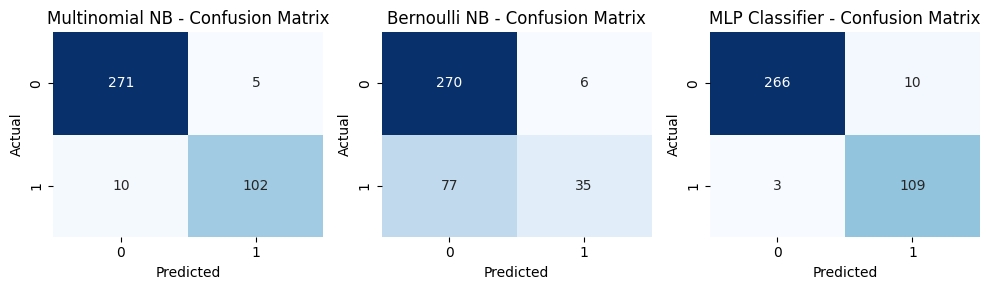

In [25]:
# Confusion Matrix

#Confusion Matrix Subplot for 3 Models
from sklearn.metrics import confusion_matrix
models = [("Multinomial NB", multinomial_nb_model), ("Bernoulli NB", bernoulli_nb_model),("MLP Classifier", mlp_classifier_model) ]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, (model_name, model) in enumerate(models):
    prediction = model.predict(x_test)
    cm = confusion_matrix(y_test, prediction)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

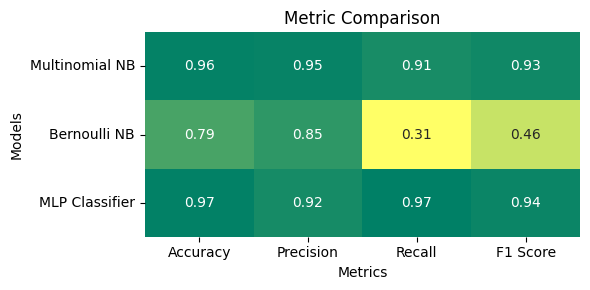

In [26]:
# Metric Comparison Heatmap

#Metric Comparison Heatmap
metric_data = []
for model_name, model in models:
    prediction = model.predict(x_test)
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    metric_data.append([accuracy, precision, recall, f1])
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
#heatmap for metric comparison
plt.figure(figsize=(6, 3))
sns.heatmap(metric_data, annot=True, fmt=".2f", cbar=False, cmap="summer_r", xticklabels=metric_labels, yticklabels=[model_name for model_name, _ in models])
plt.title("Metric Comparison")
plt.yticks(rotation=0)
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

In [29]:
# Define lists to store evaluation metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterate over each part of the dataset
for i in range(1, 6):
    # Load data
    df = pd.read_csv(f'C:/Users/Admin/Desktop/fwdproject/content/part_1.csv')

    # Preprocessing
    df=df.rename(columns={"v1":"label","v2":"text"})
    df['label'] = df['label'].map({'ham':0, 'spam':1})

    # Bag of Words
    count = CountVectorizer()
    text = count.fit_transform(df['text'])
    x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)

    # Train MLP Classifier
    mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
    mlp_classifier_model.fit(x_train, y_train)
    prediction_mlp = mlp_classifier_model.predict(x_test)

    # Train Multinomial Naive Bayes
    multinomial_nb_model = MultinomialNB()
    multinomial_nb_model.fit(x_train, y_train)
    prediction_multinomial = multinomial_nb_model.predict(x_test)

    # Train Bernoulli Naive Bayes
    bernoulli_nb_model = BernoulliNB()
    bernoulli_nb_model.fit(x_train, y_train)
    prediction_bernoulli = bernoulli_nb_model.predict(x_test)

    # Evaluate and store metrics
    accuracy_scores.append([accuracy_score(y_test, prediction_mlp),
                            accuracy_score(y_test, prediction_multinomial),
                            accuracy_score(y_test, prediction_bernoulli)])

    precision_scores.append([precision_score(y_test, prediction_mlp),
                             precision_score(y_test, prediction_multinomial),
                             precision_score(y_test, prediction_bernoulli)])

    recall_scores.append([recall_score(y_test, prediction_mlp),
                          recall_score(y_test, prediction_multinomial),
                          recall_score(y_test, prediction_bernoulli)])

    f1_scores.append([f1_score(y_test, prediction_mlp),
                      f1_score(y_test, prediction_multinomial),
                      f1_score(y_test, prediction_bernoulli)])

# Convert lists to arrays for easier calculations
accuracy_scores = np.array(accuracy_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)

# Calculate weighted averages
weighted_accuracy = np.average(accuracy_scores, axis=0, weights=[len(df) for df in parts if isinstance(df, pd.DataFrame)])
weighted_precision = np.average(precision_scores, axis=0, weights=[len(df) for df in parts if isinstance(df, pd.DataFrame)])
weighted_recall = np.average(recall_scores, axis=0, weights=[len(df) for df in parts if isinstance(df, pd.DataFrame)])
weighted_f1 = np.average(f1_scores, axis=0, weights=[len(df) for df in parts if isinstance(df, pd.DataFrame)])


# Print the weighted averages
print("Weighted Average Metrics:")
print("Weighted Average Accuracy:", weighted_accuracy)
print("Weighted Average Precision:", weighted_precision)
print("Weighted Average Recall:", weighted_recall)
print("Weighted Average F1 Score:", weighted_f1)




In [ ]:
#Load data & print samples
df = pd.read_csv('/content/part_2.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,3325,ham,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0
1,4622,spam,Subject: want your music for free ? we teach y...,1
2,2686,ham,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0
3,254,ham,Subject: buyer vs . seller on intercompany dea...,0
4,3825,spam,Subject: : : : : : : : : : : : like ma - a - s...,1


In [ ]:
#Let's drop the non-relevant unnamed columns
#df=df.drop(['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'],axis=1)

# Renaming v1 & v2 as Category & Text
df=df.rename(columns={"v1":"label","v2":"Text"})

#Sample post modifications
df.head()

,Unnamed: 0,label,text,label_num
0,3325,ham,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0
1,4622,spam,Subject: want your music for free ? we teach y...,1
2,2686,ham,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0
3,254,ham,Subject: buyer vs . seller on intercompany dea...,0
4,3825,spam,Subject: : : : : : : : : : : : like ma - a - s...,1


In [ ]:
# Exploratory Data Analysis

#Let's check the length of the dataset
print(" Total number of rows in the dataset are", len(df))

 Total number of rows in the dataset are 1292


In [ ]:
#Descriptive Summary of the dataset
df.describe()

,Unnamed: 0,label_num
count,1292.000000,1292.000000
mean,2501.003870,0.267028
std,1488.002819,0.442578
min,1.000000,0.000000
25%,1170.250000,0.000000
50%,2495.500000,0.000000
75%,3781.250000,1.000000
max,5166.000000,1.000000


In [ ]:
#Let's create a column to check of each text & plot a histogram to check the distirbution
df['Length']=df['text'].apply(len)
display(df.head())

#distribution of the data
import plotly.express as px
fig = px.histogram(df, x='Length', marginal='rug',
                   title='Histogram of Text Length')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

,Unnamed: 0,label,text,label_num,Length
0,3325,ham,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0,2315
1,4622,spam,Subject: want your music for free ? we teach y...,1,1039
2,2686,ham,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0,101
3,254,ham,Subject: buyer vs . seller on intercompany dea...,0,2294
4,3825,spam,Subject: : : : : : : : : : : : like ma - a - s...,1,1976


In [ ]:
#Lets check the distribution against categories
import plotly.express as px
fig = px.histogram(df, x='Length', color='label', marginal='rug',
                   title='Histogram of Text Length by Category')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

In [ ]:
#Let's Label the data as 0 & 1 i.e. Spam as 1 & Ham as 0
df.loc[:,'label']=df.label.map({'ham':0, 'spam':1})
df['label'] = df['label'].astype(int)
df.head()

,Unnamed: 0,label,text,label_num,Length
0,3325,0,"Subject: fw : 05 / 01 ena gas sales on hpl , t...",0,2315
1,4622,1,Subject: want your music for free ? we teach y...,1,1039
2,2686,0,"Subject: hpl nom for march 10 - 12 , 2001\r\n(...",0,101
3,254,0,Subject: buyer vs . seller on intercompany dea...,0,2294
4,3825,1,Subject: : : : : : : : : : : : like ma - a - s...,1,1976


In [ ]:
# Bag of Words

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

count = CountVectorizer()
text = count.fit_transform(df['text'])
#Train & test split
x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)
text

<1292x22297 sparse matrix of type '<class 'numpy.int64'>'
	with 113074 stored elements in Compressed Sparse Row format>

In [ ]:
#Let's print the dimentions of the train & test dataset
display('X-Train :', x_train.shape)
display('X-Test :',x_test.shape)
display('Y-Train :',y_train.shape)
display('X-Test :',y_test.shape)

'X-Train :'

(904, 22297)

'X-Test :'

(388, 22297)

'Y-Train :'

(904,)

'X-Test :'

(388,)

In [ ]:
# Training the ML models

# Neural Network
%%time
from sklearn.neural_network import MLPClassifier

mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
mlp_classifier_model.fit(x_train, y_train)

prediction = mlp_classifier_model.predict(x_test)

# Calculate and print classification metrics
print("MLP Classifier")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction)))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction)))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction)))

MLP Classifier
Accuracy score: 0.98
Precision score: 0.94
Recall score: 1.00
F1 score: 0.97
CPU times: user 21.8 s, sys: 22 s, total: 43.8 s
Wall time: 27.3 s


In [ ]:
#  Multinomial Naive Bayes

%%time
# Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

multinomial_nb_model = MultinomialNB()
multinomial_nb_model.fit(x_train, y_train)  # Train the model

prediction = multinomial_nb_model.predict(x_test)

print("Multinomial NB")
print("Accuracy score: {}". format(accuracy_score(y_test, prediction)) )
print("Precision score: {}". format(precision_score(y_test, prediction)) )
print("Recall score: {}". format(recall_score(y_test, prediction)))
print("F1 score: {}". format(f1_score(y_test, prediction)))

Multinomial NB
Accuracy score: 0.9664948453608248
Precision score: 0.9897959183673469
Recall score: 0.8899082568807339
F1 score: 0.9371980676328503
CPU times: user 30.6 ms, sys: 20.8 ms, total: 51.5 ms
Wall time: 37.5 ms


In [ ]:
# Bernoulli Naive Bayes

%%time
# Bernoulli Naive Bayes model
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bernoulli_nb_model = BernoulliNB()
bernoulli_nb_model.fit(x_train, y_train)

prediction = bernoulli_nb_model.predict(x_test)

#Evaluation
print("Bernoulli NB")
print("Accuracy score: {}". format(accuracy_score(y_test, prediction)) )
print("Precision score: {}". format(precision_score(y_test, prediction)) )
print("Recall score: {}". format(recall_score(y_test, prediction)))
print("F1 score: {}". format(f1_score(y_test, prediction)))

Bernoulli NB
Accuracy score: 0.8170103092783505
Precision score: 0.9318181818181818
Recall score: 0.3761467889908257
F1 score: 0.5359477124183006
CPU times: user 22.8 ms, sys: 15.9 ms, total: 38.6 ms
Wall time: 33 ms


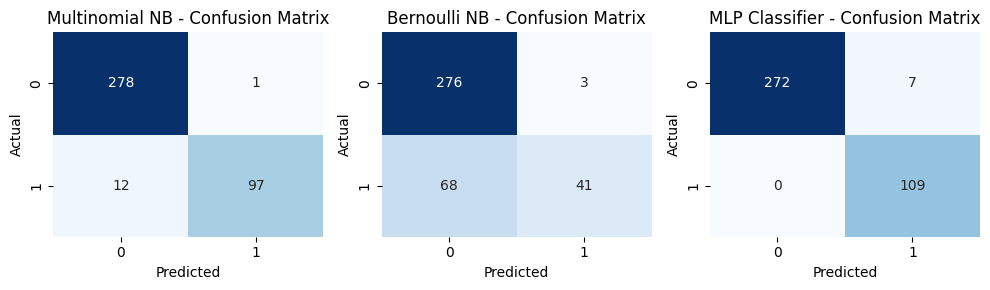

In [ ]:
# Confusion Matrix

#Confusion Matrix Subplot for 3 Models
from sklearn.metrics import confusion_matrix
models = [("Multinomial NB", multinomial_nb_model), ("Bernoulli NB", bernoulli_nb_model),("MLP Classifier", mlp_classifier_model) ]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, (model_name, model) in enumerate(models):
    prediction = model.predict(x_test)
    cm = confusion_matrix(y_test, prediction)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

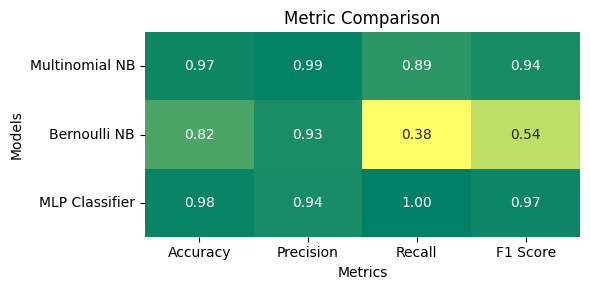

In [ ]:
# Metric Comparison Heatmap

#Metric Comparison Heatmap
metric_data = []
for model_name, model in models:
    prediction = model.predict(x_test)
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    metric_data.append([accuracy, precision, recall, f1])
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
#heatmap for metric comparison
plt.figure(figsize=(6, 3))
sns.heatmap(metric_data, annot=True, fmt=".2f", cbar=False, cmap="summer_r", xticklabels=metric_labels, yticklabels=[model_name for model_name, _ in models])
plt.title("Metric Comparison")
plt.yticks(rotation=0)
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

# Define lists to store evaluation metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
parts = range(1, 6)  # Assuming you have 5 parts

# Iterate over each part of the dataset
for i in parts:
    # Load data
    df = pd.read_csv(f'/content/part_2.csv')

    # Preprocessing
    df = df.rename(columns={"v1": "label", "v2": "text"})
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})

    # Bag of Words
    count = CountVectorizer()
    text = count.fit_transform(df['text'])
    x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)

    # Train MLP Classifier
    mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
    mlp_classifier_model.fit(x_train, y_train)
    prediction_mlp = mlp_classifier_model.predict(x_test)

    # Train Multinomial Naive Bayes
    multinomial_nb_model = MultinomialNB()
    multinomial_nb_model.fit(x_train, y_train)
    prediction_multinomial = multinomial_nb_model.predict(x_test)

    # Train Bernoulli Naive Bayes
    bernoulli_nb_model = BernoulliNB()
    bernoulli_nb_model.fit(x_train, y_train)
    prediction_bernoulli = bernoulli_nb_model.predict(x_test)

    # Evaluate and store metrics
    accuracy_scores.append([accuracy_score(y_test, prediction_mlp),
                            accuracy_score(y_test, prediction_multinomial),
                            accuracy_score(y_test, prediction_bernoulli)])

    precision_scores.append([precision_score(y_test, prediction_mlp),
                             precision_score(y_test, prediction_multinomial),
                             precision_score(y_test, prediction_bernoulli)])

    recall_scores.append([recall_score(y_test, prediction_mlp),
                          recall_score(y_test, prediction_multinomial),
                          recall_score(y_test, prediction_bernoulli)])

    f1_scores.append([f1_score(y_test, prediction_mlp),
                      f1_score(y_test, prediction_multinomial),
                      f1_score(y_test, prediction_bernoulli)])

# Convert lists to arrays for easier calculations
accuracy_scores = np.array(accuracy_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)

# Calculate weighted averages
weighted_accuracy = np.average(accuracy_scores, axis=0, weights=[len(df) for df in pd.read_csv(f'/content/part_{i}.csv') for i in parts])
weighted_precision = np.average(precision_scores, axis=0, weights=[len(df) for df in pd.read_csv(f'/content/part_{i}.csv') for i in parts])
weighted_recall = np.average(recall_scores, axis=0, weights=[len(df) for df in pd.read_csv(f'/content/part_{i}.csv') for i in parts])
weighted_f1 = np.average(f1_scores, axis=0, weights=[len(df) for df in pd.read_csv(f'/content/part_{i}.csv') for i in parts])

# Print the weighted averages
print("Weighted Average Metrics:")
print("Weighted Average Accuracy:", weighted_accuracy)
print("Weighted Average Precision:", weighted_precision)
print("Weighted Average Recall:", weighted_recall)
print("Weighted Average F1 Score:", weighted_f1)


In [ ]:
#Load data & print samples
df = pd.read_csv('/content/part_3.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,3212,ham,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0
1,4681,spam,"Subject: helpful software , unbelieveable pric...",1
2,810,ham,Subject: work distribution\r\nlogistics has ma...,0
3,3712,spam,Subject: stop s + p + a + m in its tracks demo...,1
4,3096,ham,Subject: fw : on call\r\n- - - - - original me...,0


In [ ]:
#Let's drop the non-relevant unnamed columns
#df=df.drop(['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'],axis=1)

# Renaming v1 & v2 as Category & Text
df=df.rename(columns={"v1":"label","v2":"Text"})

#Sample post modifications
df.head()

,Unnamed: 0,label,text,label_num
0,3212,ham,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0
1,4681,spam,"Subject: helpful software , unbelieveable pric...",1
2,810,ham,Subject: work distribution\r\nlogistics has ma...,0
3,3712,spam,Subject: stop s + p + a + m in its tracks demo...,1
4,3096,ham,Subject: fw : on call\r\n- - - - - original me...,0


In [ ]:
# Exploratory Data Analysis

#Let's check the length of the dataset
print(" Total number of rows in the dataset are", len(df))

 Total number of rows in the dataset are 1292


In [ ]:
#Descriptive Summary of the dataset
df.describe()

,Unnamed: 0,label_num
count,1292.000000,1292.000000
mean,2666.208978,0.296440
std,1482.405267,0.456864
min,2.000000,0.000000
25%,1372.500000,0.000000
50%,2717.500000,0.000000
75%,3934.750000,1.000000
max,5170.000000,1.000000


In [ ]:
#Let's create a column to check of each text & plot a histogram to check the distirbution
df['Length']=df['text'].apply(len)
display(df.head())

#distribution of the data
import plotly.express as px
fig = px.histogram(df, x='Length', marginal='rug',
                   title='Histogram of Text Length')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

,Unnamed: 0,label,text,label_num,Length
0,3212,ham,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0,391
1,4681,spam,"Subject: helpful software , unbelieveable pric...",1,3178
2,810,ham,Subject: work distribution\r\nlogistics has ma...,0,507
3,3712,spam,Subject: stop s + p + a + m in its tracks demo...,1,908
4,3096,ham,Subject: fw : on call\r\n- - - - - original me...,0,678


In [ ]:
#Lets check the distribution against categories
import plotly.express as px
fig = px.histogram(df, x='Length', color='label', marginal='rug',
                   title='Histogram of Text Length by Category')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

In [ ]:
#Let's Label the data as 0 & 1 i.e. Spam as 1 & Ham as 0
df.loc[:,'label']=df.label.map({'ham':0, 'spam':1})
df['label'] = df['label'].astype(int)
df.head()

,Unnamed: 0,label,text,label_num,Length
0,3212,0,Subject: panenergy 4 / 01\r\ndaren :\r\ndid we...,0,391
1,4681,1,"Subject: helpful software , unbelieveable pric...",1,3178
2,810,0,Subject: work distribution\r\nlogistics has ma...,0,507
3,3712,1,Subject: stop s + p + a + m in its tracks demo...,1,908
4,3096,0,Subject: fw : on call\r\n- - - - - original me...,0,678


In [ ]:
# Bag of Words

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

count = CountVectorizer()
text = count.fit_transform(df['text'])
#Train & test split
x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)
text

<1292x22913 sparse matrix of type '<class 'numpy.int64'>'
	with 116617 stored elements in Compressed Sparse Row format>

In [ ]:
#Let's print the dimentions of the train & test dataset
display('X-Train :', x_train.shape)
display('X-Test :',x_test.shape)
display('Y-Train :',y_train.shape)
display('X-Test :',y_test.shape)

'X-Train :'

(904, 22913)

'X-Test :'

(388, 22913)

'Y-Train :'

(904,)

'X-Test :'

(388,)

In [ ]:
# Training the ML models

# Neural Network
%%time
from sklearn.neural_network import MLPClassifier

mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
mlp_classifier_model.fit(x_train, y_train)

prediction = mlp_classifier_model.predict(x_test)

# Calculate and print classification metrics
print("MLP Classifier")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction)))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction)))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction)))

MLP Classifier
Accuracy score: 0.96
Precision score: 0.89
Recall score: 0.97
F1 score: 0.93
CPU times: user 20.9 s, sys: 21.4 s, total: 42.3 s
Wall time: 25.2 s


In [ ]:
#  Multinomial Naive Bayes

%%time
# Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

multinomial_nb_model = MultinomialNB()
multinomial_nb_model.fit(x_train, y_train)  # Train the model

prediction = multinomial_nb_model.predict(x_test)

print("Multinomial NB")
print("Accuracy score: {}". format(accuracy_score(y_test, prediction)) )
print("Precision score: {}". format(precision_score(y_test, prediction)) )
print("Recall score: {}". format(recall_score(y_test, prediction)))
print("F1 score: {}". format(f1_score(y_test, prediction)))

Multinomial NB
Accuracy score: 0.979381443298969
Precision score: 0.9897959183673469
Recall score: 0.9326923076923077
F1 score: 0.9603960396039605
CPU times: user 22.3 ms, sys: 20.3 ms, total: 42.6 ms
Wall time: 23.8 ms


In [ ]:
# Bernoulli Naive Bayes

%%time
# Bernoulli Naive Bayes model
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bernoulli_nb_model = BernoulliNB()
bernoulli_nb_model.fit(x_train, y_train)

prediction = bernoulli_nb_model.predict(x_test)

#Evaluation
print("Bernoulli NB")
print("Accuracy score: {}". format(accuracy_score(y_test, prediction)) )
print("Precision score: {}". format(precision_score(y_test, prediction)) )
print("Recall score: {}". format(recall_score(y_test, prediction)))
print("F1 score: {}". format(f1_score(y_test, prediction)))

Bernoulli NB
Accuracy score: 0.8402061855670103
Precision score: 0.9565217391304348
Recall score: 0.4230769230769231
F1 score: 0.5866666666666667
CPU times: user 33 ms, sys: 19.1 ms, total: 52.1 ms
Wall time: 34.2 ms


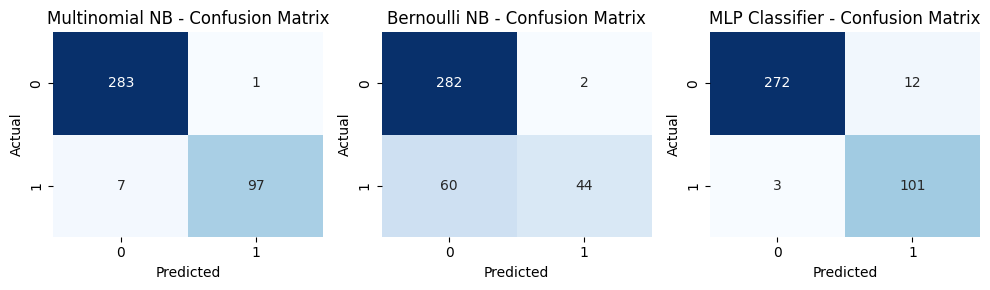

In [ ]:
# Confusion Matrix

#Confusion Matrix Subplot for 3 Models
from sklearn.metrics import confusion_matrix
models = [("Multinomial NB", multinomial_nb_model), ("Bernoulli NB", bernoulli_nb_model),("MLP Classifier", mlp_classifier_model) ]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, (model_name, model) in enumerate(models):
    prediction = model.predict(x_test)
    cm = confusion_matrix(y_test, prediction)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

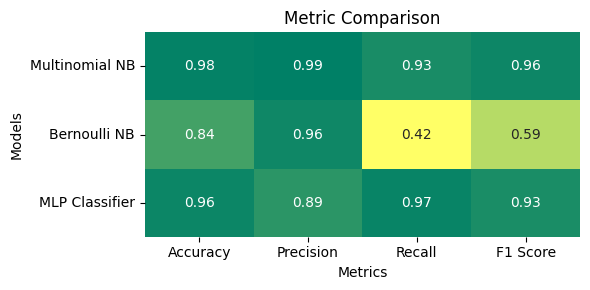

In [ ]:
# Metric Comparison Heatmap

#Metric Comparison Heatmap
metric_data = []
for model_name, model in models:
    prediction = model.predict(x_test)
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    metric_data.append([accuracy, precision, recall, f1])
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
#heatmap for metric comparison
plt.figure(figsize=(6, 3))
sns.heatmap(metric_data, annot=True, fmt=".2f", cbar=False, cmap="summer_r", xticklabels=metric_labels, yticklabels=[model_name for model_name, _ in models])
plt.title("Metric Comparison")
plt.yticks(rotation=0)
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

In [ ]:
# Define lists to store evaluation metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterate over each part of the dataset
for i in range(1, 6):
    # Load data
    df = pd.read_csv(f'/content/part_3.csv')

    # Preprocessing
    df=df.rename(columns={"v1":"label","v2":"text"})
    df['label'] = df['label'].map({'ham':0, 'spam':1})

    # Bag of Words
    count = CountVectorizer()
    text = count.fit_transform(df['text'])
    x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)

    # Train MLP Classifier
    mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
    mlp_classifier_model.fit(x_train, y_train)
    prediction_mlp = mlp_classifier_model.predict(x_test)

    # Train Multinomial Naive Bayes
    multinomial_nb_model = MultinomialNB()
    multinomial_nb_model.fit(x_train, y_train)
    prediction_multinomial = multinomial_nb_model.predict(x_test)

    # Train Bernoulli Naive Bayes
    bernoulli_nb_model = BernoulliNB()
    bernoulli_nb_model.fit(x_train, y_train)
    prediction_bernoulli = bernoulli_nb_model.predict(x_test)

    # Evaluate and store metrics
    accuracy_scores.append([accuracy_score(y_test, prediction_mlp),
                            accuracy_score(y_test, prediction_multinomial),
                            accuracy_score(y_test, prediction_bernoulli)])

    precision_scores.append([precision_score(y_test, prediction_mlp),
                             precision_score(y_test, prediction_multinomial),
                             precision_score(y_test, prediction_bernoulli)])

    recall_scores.append([recall_score(y_test, prediction_mlp),
                          recall_score(y_test, prediction_multinomial),
                          recall_score(y_test, prediction_bernoulli)])

    f1_scores.append([f1_score(y_test, prediction_mlp),
                      f1_score(y_test, prediction_multinomial),
                      f1_score(y_test, prediction_bernoulli)])

# Convert lists to arrays for easier calculations
accuracy_scores = np.array(accuracy_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)

# Calculate weighted averages
weighted_accuracy = np.average(accuracy_scores, axis=0, weights=[len(df) for df in parts])
weighted_precision = np.average(precision_scores, axis=0, weights=[len(df) for df in parts])
weighted_recall = np.average(recall_scores, axis=0, weights=[len(df) for df in parts])
weighted_f1 = np.average(f1_scores, axis=0, weights=[len(df) for df in parts])

# Print the weighted averages
print("Weighted Average Metrics:")
print("Weighted Average Accuracy:", weighted_accuracy)
print("Weighted Average Precision:", weighted_precision)
print("Weighted Average Recall:", weighted_recall)
print("Weighted Average F1 Score:", weighted_f1)




In [ ]:
#Load data & print samples
df = pd.read_csv('/content/part_4.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,1404,ham,Subject: re : june 00 production - o ' connor ...,0
1,1555,ham,Subject: intraday eastrans nominations change ...,0
2,2001,ham,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0
3,3718,spam,Subject: exclusive positions in montanayoocwo\...,1
4,2134,ham,Subject: natural gas nomination for december 2...,0


In [ ]:
#Let's drop the non-relevant unnamed columns
#df=df.drop(['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'],axis=1)

# Renaming v1 & v2 as Category & Text
df=df.rename(columns={"v1":"label","v2":"Text"})

#Sample post modifications
df.head()

,Unnamed: 0,label,text,label_num
0,1404,ham,Subject: re : june 00 production - o ' connor ...,0
1,1555,ham,Subject: intraday eastrans nominations change ...,0
2,2001,ham,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0
3,3718,spam,Subject: exclusive positions in montanayoocwo\...,1
4,2134,ham,Subject: natural gas nomination for december 2...,0


In [ ]:
# Exploratory Data Analysis

#Let's check the length of the dataset
print(" Total number of rows in the dataset are", len(df))

In [ ]:
#Descriptive Summary of the dataset
df.describe()

In [ ]:
#Let's create a column to check of each text & plot a histogram to check the distirbution
df['Length']=df['text'].apply(len)
display(df.head())

#distribution of the data
import plotly.express as px
fig = px.histogram(df, x='Length', marginal='rug',
                   title='Histogram of Text Length')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

,Unnamed: 0,label,text,label_num,Length
0,1404,ham,Subject: re : june 00 production - o ' connor ...,0,1172
1,1555,ham,Subject: intraday eastrans nominations change ...,0,2116
2,2001,ham,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0,114
3,3718,spam,Subject: exclusive positions in montanayoocwo\...,1,966
4,2134,ham,Subject: natural gas nomination for december 2...,0,2575


In [ ]:
#Lets check the distribution against categories
import plotly.express as px
fig = px.histogram(df, x='Length', color='label', marginal='rug',
                   title='Histogram of Text Length by Category')
fig.update_layout(
    xaxis_title='Length',
    yaxis_title='Frequency',
    showlegend=True)

In [ ]:
#Let's Label the data as 0 & 1 i.e. Spam as 1 & Ham as 0
df.loc[:,'label']=df.label.map({'ham':0, 'spam':1})
df['label'] = df['label'].astype(int)
df.head()

,Unnamed: 0,label,text,label_num,Length
0,1404,0,Subject: re : june 00 production - o ' connor ...,0,1172
1,1555,0,Subject: intraday eastrans nominations change ...,0,2116
2,2001,0,"Subject: enron / hpl actuals - nov . 7 , 2000\...",0,114
3,3718,1,Subject: exclusive positions in montanayoocwo\...,1,966
4,2134,0,Subject: natural gas nomination for december 2...,0,2575


In [ ]:
# Bag of Words

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

count = CountVectorizer()
text = count.fit_transform(df['text'])
#Train & test split
x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)
text

<1295x20829 sparse matrix of type '<class 'numpy.int64'>'
	with 114446 stored elements in Compressed Sparse Row format>

In [ ]:
#Let's print the dimentions of the train & test dataset
display('X-Train :', x_train.shape)
display('X-Test :',x_test.shape)
display('Y-Train :',y_train.shape)
display('X-Test :',y_test.shape)

'X-Train :'

(906, 20829)

'X-Test :'

(389, 20829)

'Y-Train :'

(906,)

'X-Test :'

(389,)

In [ ]:
# Training the ML models

# Neural Network
%%time
from sklearn.neural_network import MLPClassifier

mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
mlp_classifier_model.fit(x_train, y_train)

prediction = mlp_classifier_model.predict(x_test)

# Calculate and print classification metrics
print("MLP Classifier")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction)))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction)))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction)))

MLP Classifier
Accuracy score: 0.97
Precision score: 0.93
Recall score: 0.96
F1 score: 0.94
CPU times: user 18.6 s, sys: 12.6 s, total: 31.2 s
Wall time: 19.9 s


In [ ]:
#  Multinomial Naive Bayes

%%time
# Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

multinomial_nb_model = MultinomialNB()
multinomial_nb_model.fit(x_train, y_train)  # Train the model

prediction = multinomial_nb_model.predict(x_test)

print("Multinomial NB")
print("Accuracy score: {}". format(accuracy_score(y_test, prediction)) )
print("Precision score: {}". format(precision_score(y_test, prediction)) )
print("Recall score: {}". format(recall_score(y_test, prediction)))
print("F1 score: {}". format(f1_score(y_test, prediction)))

Multinomial NB
Accuracy score: 0.9691516709511568
Precision score: 0.963963963963964
Recall score: 0.9304347826086956
F1 score: 0.9469026548672567
CPU times: user 30.5 ms, sys: 16.2 ms, total: 46.6 ms
Wall time: 46.6 ms


In [ ]:
# Bernoulli Naive Bayes

%%time
# Bernoulli Naive Bayes model
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bernoulli_nb_model = BernoulliNB()
bernoulli_nb_model.fit(x_train, y_train)

prediction = bernoulli_nb_model.predict(x_test)

#Evaluation
print("Bernoulli NB")
print("Accuracy score: {}". format(accuracy_score(y_test, prediction)) )
print("Precision score: {}". format(precision_score(y_test, prediction)) )
print("Recall score: {}". format(recall_score(y_test, prediction)))
print("F1 score: {}". format(f1_score(y_test, prediction)))

Bernoulli NB
Accuracy score: 0.8097686375321337
Precision score: 0.9361702127659575
Recall score: 0.3826086956521739
F1 score: 0.54320987654321
CPU times: user 28.1 ms, sys: 3.19 ms, total: 31.3 ms
Wall time: 36.2 ms


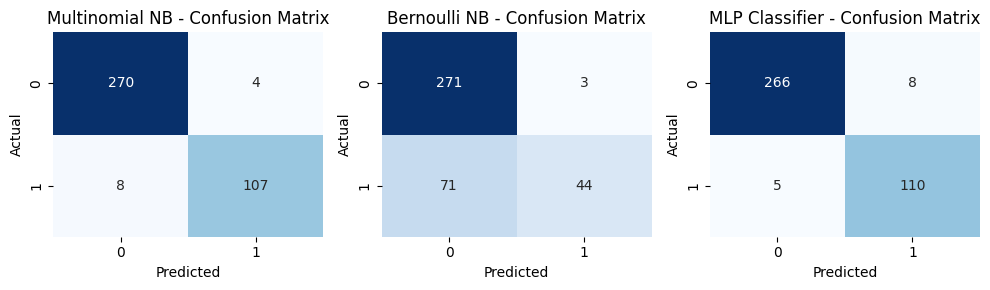

In [ ]:
# Confusion Matrix

#Confusion Matrix Subplot for 3 Models
from sklearn.metrics import confusion_matrix
models = [("Multinomial NB", multinomial_nb_model), ("Bernoulli NB", bernoulli_nb_model),("MLP Classifier", mlp_classifier_model) ]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, (model_name, model) in enumerate(models):
    prediction = model.predict(x_test)
    cm = confusion_matrix(y_test, prediction)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

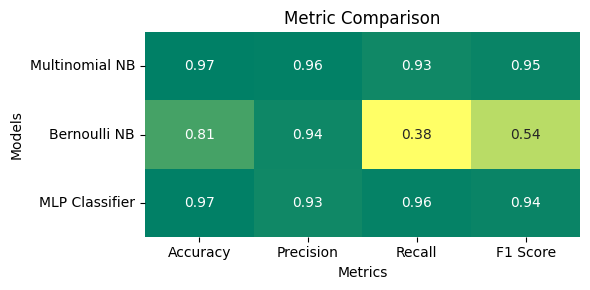

In [ ]:
# Metric Comparison Heatmap

#Metric Comparison Heatmap
metric_data = []
for model_name, model in models:
    prediction = model.predict(x_test)
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    metric_data.append([accuracy, precision, recall, f1])
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
#heatmap for metric comparison
plt.figure(figsize=(6, 3))
sns.heatmap(metric_data, annot=True, fmt=".2f", cbar=False, cmap="summer_r", xticklabels=metric_labels, yticklabels=[model_name for model_name, _ in models])
plt.title("Metric Comparison")
plt.yticks(rotation=0)
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

In [ ]:
# Define lists to store evaluation metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterate over each part of the dataset
for i in range(1, 6):
    # Load data
    df = pd.read_csv(f'/content/part_4.csv')

    # Preprocessing
    df=df.rename(columns={"v1":"label","v2":"text"})
    df['label'] = df['label'].map({'ham':0, 'spam':1})

    # Bag of Words
    count = CountVectorizer()
    text = count.fit_transform(df['text'])
    x_train, x_test, y_train, y_test = train_test_split(text, df['label'], test_size=0.30, random_state=100)

    # Train MLP Classifier
    mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
    mlp_classifier_model.fit(x_train, y_train)
    prediction_mlp = mlp_classifier_model.predict(x_test)

    # Train Multinomial Naive Bayes
    multinomial_nb_model = MultinomialNB()
    multinomial_nb_model.fit(x_train, y_train)
    prediction_multinomial = multinomial_nb_model.predict(x_test)

    # Train Bernoulli Naive Bayes
    bernoulli_nb_model = BernoulliNB()
    bernoulli_nb_model.fit(x_train, y_train)
    prediction_bernoulli = bernoulli_nb_model.predict(x_test)

    # Evaluate and store metrics
    accuracy_scores.append([accuracy_score(y_test, prediction_mlp),
                            accuracy_score(y_test, prediction_multinomial),
                            accuracy_score(y_test, prediction_bernoulli)])

    precision_scores.append([precision_score(y_test, prediction_mlp),
                             precision_score(y_test, prediction_multinomial),
                             precision_score(y_test, prediction_bernoulli)])

    recall_scores.append([recall_score(y_test, prediction_mlp),
                          recall_score(y_test, prediction_multinomial),
                          recall_score(y_test, prediction_bernoulli)])

    f1_scores.append([f1_score(y_test, prediction_mlp),
                      f1_score(y_test, prediction_multinomial),
                      f1_score(y_test, prediction_bernoulli)])

# Convert lists to arrays for easier calculations
accuracy_scores = np.array(accuracy_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)

# Calculate weighted averages
weighted_accuracy = np.average(accuracy_scores, axis=0, weights=[len(df) for df in parts])
weighted_precision = np.average(precision_scores, axis=0, weights=[len(df) for df in parts])
weighted_recall = np.average(recall_scores, axis=0, weights=[len(df) for df in parts])
weighted_f1 = np.average(f1_scores, axis=0, weights=[len(df) for df in parts])

# Print the weighted averages
print("Weighted Average Metrics:")
print("Weighted Average Accuracy:", weighted_accuracy)
print("Weighted Average Precision:", weighted_precision)
print("Weighted Average Recall:", weighted_recall)
print("Weighted Average F1 Score:", weighted_f1)




In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Define a function to analyze and fine-tune the model
def analyze_and_finetune(results):
    # Aggregate the results from all clients
    accuracies = [result["accuracy"] for result in results]
    avg_accuracy = np.mean(accuracies)
    print("Average accuracy across clients:", avg_accuracy)

    # Fine-tune the model based on the analysis
    # Example: Adjust hyperparameters, train for more rounds, etc.

# Load the results from federated learning rounds
# Example: results = load_results_from_training_rounds()

# Analyze results and fine-tune the model
# Example: analyze_and_finetune(results)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Load the test dataset

# Load the test dataset with specified encoding
encodings = ['utf-8', 'latin1', 'iso-8859-1', 'utf-16']
for encoding in encodings:
    try:
        test_df = pd.read_csv('/content/SMS_test.csv', encoding=encoding).dropna()
        break  # Stop trying encodings if successful
    except UnicodeDecodeError:
        print(f"Failed to read using encoding: {encoding}")

X_test = test_df["Message_body"].values
y_test = test_df["Label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Perform final evaluation on the federated model
def evaluate_model(weights):
    # Initialize the model with weights from the server
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    classifier.coef_, classifier.intercept_ = weights

    # Make predictions on the test data
    y_pred = classifier.predict(X_test_transformed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy



# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)


# Create a ClientManager
client_manager = fl.server.client_manager.SimpleClientManager()

# Initialize the Server with the ClientManager
server = fl.server.Server(client_manager=client_manager, strategy=strategy)

server = fl.server.Server(strategy=strategy)


# Evaluate the federated model on the test data
server = fl.server.Server(strategy=strategy)
accuracy = evaluate_model(server.get_parameters())

print("Test Accuracy:", accuracy)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Function to analyze evaluation results and fine-tune the model
def analyze_and_finetune(accuracy):
    # Analyze the evaluation results
    print("Current accuracy:", accuracy)

    # Fine-tune the model based on the analysis
    # Example: Adjust hyperparameters, train for more rounds, etc.

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Load the test dataset
test_df = pd.read_csv('/content/SMS_test.csv').dropna()
X_test = test_df["Message_body"].values
y_test = test_df["Label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Perform final evaluation on the federated model
def evaluate_model(weights):
    # Initialize the model with weights from the server
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    classifier.coef_, classifier.intercept_ = weights

    # Make predictions on the test data
    y_pred = classifier.predict(X_test_transformed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Evaluate the federated model on the test data
server = fl.server.Server(strategy=strategy)
accuracy = evaluate_model(server.get_parameters())

# Analyze evaluation results and fine-tune the model
analyze_and_finetune(accuracy)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        accuracy = accuracy_score(self.y, y_pred)
        return accuracy, len(self.X), {"accuracy": accuracy}

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

# Join the client threads
for client_thread in client_threads:
    client_thread.join()

# Load the test dataset
test_df = pd.read_csv('/content/test_data.csv').dropna()
X_test = test_df["text"].values
y_test = test_df["label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Perform final evaluation on the federated model
def evaluate_model(weights):
    # Initialize the model with weights from the server
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    classifier.coef_, classifier.intercept_ = weights

    # Make predictions on the test data
    y_pred = classifier.predict(X_test_transformed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Evaluate the federated model on the test data
server = fl.server.Server(strategy=strategy)
accuracy = evaluate_model(server.get_parameters())

# Ensure privacy compliance
def ensure_privacy_compliance():
    # Implement privacy compliance measures here
    # Example: Anonymization, differential privacy, data encryption, etc.

# Ensure privacy compliance before deploying the federated model
ensure_privacy_compliance()


In [ ]:
from flask import Flask, request, jsonify
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
import flwr as fl
import threading

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        return y_pred

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Start clients in separate threads
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

for client_thread in client_threads:
    client_thread.join()

# Load the test dataset
test_df = pd.read_csv('/content/SMS_test.csv').dropna()
X_test = test_df["text"].values
y_test = test_df["label"].values

# Vectorize the test data
vectorizer = TfidfVectorizer()
X_test_transformed = vectorizer.fit_transform(X_test)

# Define a Flask web service
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    text = data['text']

    # Vectorize the input text
    text_transformed = vectorizer.transform([text])

    # Make predictions using the federated model
    predictions = server.predict(text_transformed.toarray())

    # Return the predictions
    return jsonify({'prediction': predictions[0]})

if __name__ == '__main__':
    app.run(debug=True)


In [ ]:
import time
import threading
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
import flwr as fl

# Define the PhishingClient class
class PhishingClient(fl.client.NumPyClient):
    def __init__(self, data_path, vectorizer, classifier):
        self.data_path = data_path
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.load_data()

    def load_data(self):
        df = pd.read_csv(self.data_path).dropna()
        self.X = df["text"].values
        self.y = df["label"].values

    def get_parameters(self):
        return [self.classifier.coef_, self.classifier.intercept_]

    def set_parameters(self, parameters):
        self.classifier.coef_, self.classifier.intercept_ = parameters

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        X_train = self.vectorizer.fit_transform(self.X)
        self.classifier.partial_fit(X_train, self.y, classes=np.unique(self.y))
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        X_test = self.vectorizer.transform(self.X)
        y_pred = self.classifier.predict(X_test)
        return y_pred

# Define the client function
def client_fn(cid: str):
    data_path = f"/content/part_{int(cid)+1}.csv"
    vectorizer = TfidfVectorizer()
    classifier = SGDClassifier(loss='log', max_iter=1, tol=None)
    return PhishingClient(data_path, vectorizer, classifier)

# Define the federated learning strategy
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average
)

# Function to start a client
def start_client(client_id):
    client = client_fn(client_id)
    fl.client.start_numpy_client(server_address="localhost:8081", client=client)

# Start clients in separate threads
client_threads = []
for cid in range(4):
    client_thread = threading.Thread(target=start_client, args=(str(cid),))
    client_threads.append(client_thread)
    client_thread.start()

for client_thread in client_threads:
    client_thread.join()

# Define a function for monitoring model performance
def monitor_model_performance():
    while True:
        # Retrieve model parameters from the server
        weights = server.get_parameters()

        # Perform evaluation on the test data
        y_pred = server.evaluate(weights)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Log accuracy or perform further analysis

        # Sleep for a specified interval
        time.sleep(60)  # Adjust interval as needed

# Start the monitoring thread
monitor_thread = threading.Thread(target=monitor_model_performance)
monitor_thread.start()

# Define a function for handling failures and maintaining system stability
def handle_failures():
    while True:
        # Monitor system status and handle failures
        # Example: Restart failed clients, recover from communication errors, etc.

        # Sleep for a specified interval
        time.sleep(300)  # Adjust interval as needed

# Start the maintenance thread
maintenance_thread = threading.Thread(target=handle_failures)
maintenance_thread.start()

# Run the Flower server
server = fl.server.Server(strategy=strategy)
server.run(config={"num_rounds": 5})
